This notebook illustrates how to use the VNS heuristic to approximate the Pareto frontier of the multi-objective knapsack problem.
Michel Bierlaire
May 20, 2025

In [1]:
from __future__ import annotations
import os
import logging
import random
import numpy as np
from biogeme_optimization.neighborhood import Neighborhood
from biogeme_optimization.pareto import SetElement
from biogeme_optimization.vns import ParetoClass, vns

# Multi-Objective Knapsack Problem

## Problem Definition

The **Multi-Objective Knapsack Problem** extends the classical 0-1 knapsack problem by introducing multiple objectives that are often in conflict.

In this case, each item is associated with:

- A **utility** value, which we want to **maximize**
- A **weight**, which we want to **minimize**

The total weight of selected items must not exceed a specified **capacity**.

## Mathematical Formulation

Let there be `n` items, indexed by `i = 1, 2, ..., n`. Each item `i` has:

- `u_i`: utility (value)
- `c_i`: cost
- `w_i`: weight

Define a binary decision variable:
$$
x_i =
\begin{cases}
1 & \text{if item } i \text{ is selected} \\
0 & \text{otherwise}
\end{cases}
$$

**Objectives:**

- Maximize total utility: `U(x) = sum(u_i * x_i for i in 1..n)`
- Minimize total cost: `C(x) = sum(c_i * x_i for i in 1..n)`

**Constraint:**

- `sum(w_i * x_i for i in 1..n) <= W`  
  where `W` is the capacity of the knapsack

## Conflicting Objectives

- Selecting items to **maximize utility** usually increases total weight.
- Selecting items to **minimize cost** may lower total utility.

This trade-off means no single "best" solution exists—there is a **set of Pareto-optimal solutions**.

## Pareto Optimality

A solution is **Pareto optimal** if there is no other feasible solution that:

- Has **higher utility** *and*
- Has **lower cost**

The set of all such solutions is known as the **Pareto front**.


# Instance for the example

In [2]:
UTILITY = [80, 31, 48, 17, 27, 84, 34, 39, 46, 58, 23, 67]
COST = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
WEIGHT = [84, 27, 47, 22, 21, 96, 42, 46, 54, 53, 32, 78]
CAPACITY = 300

In [3]:
number_of_items = len(UTILITY)
number_of_items

12

# Definition of a solution

We first need to implement a class characterizing a solution. In this case, a solution is the value of $x_i$ for each item $i$. In order to communication with the VNS algorithm, each solution must be coded into a string. For the knapsack example, a solution is characterized by the sequence of $x_i$, separated by an hyphen. 

The string `0-0-0-0-0-0-0-0-0-0-0-0` represents an empty sack. The string `1-1-1-1-1-1-1-1-1-1-1-1-1` represents a sack will all items included. And so on.

The following functions are implemented:
- `__init__`: the constructor takes a list of decisions as input and creates an instance of a `Sack` object.
- `from_string_representation`: another constructor that takes a string representation as input and creates an instance of a `Sack`object.
- `generate_string_representation`: function that generates the string representation of the sack.  
- `get_element`: the role of this function is to generate a object of class `SetElement` that is designed to be inserted in the Pareto set. It associates the string representation of a solution with the list of values of the objective functions, assuming that all objectives must be minimized. In our example, it means that the sign of the total utility must be changed.
- `describe`: provides a short description of the sack, just for reporting.

In [4]:
class Sack:
    """Implements a solution. Here, a sack configuration."""

    SEPARATOR = '-'
    utility_data = None
    weight_data = None
    cost_data = None

    def __init__(self, decisions: list[int]) -> None:
        """Creates a sack from a list of decisions.

        :param decisions: decisions coded as a lisr of 0/1

        :Example:
            >>> Sack.utility_data = [10, 20, 30, 40, 50, 60]
            >>> Sack.weight_data = [1, 2, 3, 4, 5, 6]
            >>> a_sack = Sack([0, 1, 1, 0, 0, 1])
            >>> a_sack.utility
            110
            >>> a_sack.weight
            11"""
        self.decisions = decisions
        self.utility = sum(x * u for x, u in zip(self.decisions, self.utility_data))
        self.weight = sum(x * w for x, w in zip(self.decisions, self.weight_data))
        self.cost = sum(x * c for x, c in zip(self.decisions, self.cost_data))

    @classmethod
    def from_string_representation(cls, string_representation: str) -> Sack:
        """
        Creates a sack from a string representation.

        :param string_representation: the string representation of a sack using 0/1 values separated by hyphens.

        :Example:
            >>> Sack.utility_data = [10, 20, 30, 40, 50, 60]
            >>> Sack.weight_data = [1, 2, 3, 4, 5, 6]
            >>> a_sack = Sack.from_string_representation('0-1-1-0-0-1')
            >>> a_sack.utility
            110
            >>> a_sack.weight
            11
        """
        decisions = [int(i) for i in string_representation.split(cls.SEPARATOR)]
        return Sack(decisions=decisions)

    def generate_string_representation(self) -> str:
        """Provide a string ID for the sack

        :return: identifier of the solution. Used to organize the Pareto set.
        :rtype: str
        """
        return self.SEPARATOR.join([str(x) for x in self.decisions])

    def get_element(self) -> SetElement:
        """Implementation of abstract method"""
        return SetElement(
            self.generate_string_representation(), [-self.utility, self.cost]
        )

    def describe(self):
        """Short description of the solution. Used for reporting.

        :return: short description of the solution.
        :rtype: str
        """
        return f'{self.generate_string_representation()}: U={self.utility} C={self.cost} W={self.weight}'



# Operators and neighborhood

The core of the algorithm relies on the concepts of operators and neighborhoods. The *neighborhood* of a solution consists of all solutions that can be reached by applying simple modifications to it. Each such modification is carried out by an *operator*, which defines a specific transformation rule used to explore the solution space.

Each operator is associated with a size parameter, which controls the magnitude of its effect on the solution.

In the Python implementation, an operator takes as input an object of type `SetElement` characterizing a solution, and the size. It returns a tuple with a new object of type `SetElement`, as well as the number of modifications to the solutions that have actually been made. If no modification has been made, the tuple ``None, 0``is returned.
  

In our example, the first operator adds a number of randomly selected items in the sack. The number itself corresponds to the size of the operator.   

In [5]:
def add_items(element: SetElement, size: int = 1) -> tuple[SetElement | None, int]:
    """Add ``size`` items in the sack

    :param element: representation of the current sack
    :param size: number of items to add into the sack
    :return: representation of the new sack, and number of changes actually made
    """
    solution = Sack.from_string_representation(element.element_id)
    absent = [i for i, x in enumerate(solution.decisions) if x == 0]
    if not absent:
        return None, 0
    random.shuffle(absent)
    n = min(len(absent), size)
    x_plus = solution.decisions.copy()
    for i in absent[:n]:
        x_plus[i] = 1
    neighbor = Sack(x_plus)
    return neighbor.get_element(), n

The second operator removes a number of randomly selected items in the sack. The number itself corresponds to the size of the operator.

In [6]:
def remove_items(element: SetElement, size: int = 1) -> tuple[SetElement | None, int]:
    """Remove ``size`` items from the sack

    :param element: representation of the current sack
    :param size: number of items to remove from the sack

    :return: representation of the new sack, and number of changes actually made
    """
    solution = Sack.from_string_representation(element.element_id)
    present = [i for i, x in enumerate(solution.decisions) if x == 1]
    if not present:
        return None, 0
    random.shuffle(present)
    n = min(len(present), size)
    x_plus = solution.decisions.copy()
    for i in present[:n]:
        x_plus[i] = 0
    neighbor = Sack(x_plus)
    return neighbor.get_element(), n

The third and last operator changes the status of a number of randomly selected items in the sack. Changing the status means that the object is rmeoved if it was in the sack, and is added if it was out of the sack. The number itself corresponds to the size of the operator.

In [7]:
def change_decisions(
    element: SetElement, size: int = 1
) -> tuple[SetElement | None, int]:
    """Change the status of ``size`` items in the sack.

    :param element: representation of the current sack
    :param size: number of items to modify
    :return: representation of the new sack, and number of changes actually made

    """
    solution = Sack.from_string_representation(element.element_id)
    length = len(solution.decisions)
    n = min(length, size)
    order = np.random.permutation(length)
    x_plus = solution.decisions.copy()
    for i in range(n):
        x_plus[order[i]] = 1 - x_plus[order[i]]
    neighbor = Sack(x_plus)
    return neighbor.get_element(), n

Finally, we group all the data about the problem as well as all the operators in an object inheriting from the class `Neighborhood`, that will be used by the algorithm. It implements two functions:
- `__init__`: the constructor, that must send the operators to the parent class using the `super().__init__(self.operators)` statement,
- `is_valid`: a function that identifies feasible solutions.

In [8]:
class Knapsack(Neighborhood):
    """Class characterizing the knapsack problem. Note the
    inheritance from the abstract class Neighborhood. It guarantees
    the compliance with the requirements of the algorithm.

    """

    def __init__(self, utility: list[float], weight: list[float], capacity: float):
        """Ctor"""
        self.utility = utility
        self.weight = weight
        self.capacity = capacity
        self.operators = {
            'Add items': add_items,
            'Remove items': remove_items,
            'Change decision for items': change_decisions,
        }
        self.last_operator = None
        super().__init__(self.operators)

    def is_valid(self, element: SetElement) -> tuple[bool, str | None]:
        """Check if the sack verifies the capacity constraint

        Implementation of the abstract method

        :param element: representation of the sack to check
        :return: True if the capacity constraint is verified. The string provides a message if the solution is not valid
        """
        solution = Sack.from_string_representation(element.element_id)
        if solution.weight <= self.capacity:
            return True, None
        return False, 'Infeasible sack'


# Running the algorithm

We are now ready to run the algorithm. First, we specify a file name to store the Pareto solutions. WE erase it if it has been generated in a previous run.

In [9]:
FILE_NAME = 'knapsack.pareto'
if os.path.exists(FILE_NAME):
    os.remove(FILE_NAME)

Then, we send the data of the problem to the `Sack`class.

In [10]:
Sack.utility_data = UTILITY
Sack.weight_data = WEIGHT
Sack.cost_data = COST

We define a first sack as initial solution. We use an empty sack, so that the capacity constraint is trivially verified. 

In [11]:
empty_sack = Sack([0] * number_of_items)
print(empty_sack.describe())

0-0-0-0-0-0-0-0-0-0-0-0: U=0 C=0 W=0


We then create the object that manages the Parero set. In this example, we specify that a maximum of 5 neighborhood should be considered in order to improve one specific solution.

In [12]:
the_pareto = ParetoClass(max_neighborhood=5, pareto_file=FILE_NAME)

We then create the object representing the problem to solve, using the class defined above. 

In [13]:
the_knapsack = Knapsack(utility=UTILITY, weight=WEIGHT, capacity=CAPACITY)

And, finally, we run the algorithm, after setting the logger to have some reporting of the iterations.

In [14]:
logger = logging.getLogger('biogeme_optimization')
logger.setLevel(logging.INFO)
formatter = logging.Formatter('%(message)s ')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.INFO)
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)

In [15]:
the_pareto = vns(
    problem=the_knapsack,
    first_solutions=[empty_sack.get_element()],
    pareto=the_pareto,
    number_of_neighbors=5,
)

0-0-0-0-0-0-0-0-0-0-0-0 [0, 0] 
Initial pareto: 1 
Attempt 0/100 
Considering neighbor 0/5 for current solution 
*** New pareto solution:  
0-1-0-0-0-0-0-0-0-0-0-0 [-31, 2] 
Attempt 1/100 
Considering neighbor 0/5 for current solution 
*** New pareto solution:  
0-1-0-0-0-0-0-0-1-0-0-0 [-77, 11] 
Attempt 2/100 
Considering neighbor 0/5 for current solution 
*** New pareto solution:  
1-0-0-0-0-0-0-0-0-0-0-0 [-80, 1] 
Attempt 3/100 
Considering neighbor 0/5 for current solution 
Considering neighbor 1/5 for current solution 
Attempt 4/100 
Considering neighbor 0/5 for current solution 
*** New pareto solution:  
0-1-0-0-0-0-0-0-1-0-0-1 [-144, 23] 
Attempt 5/100 
Considering neighbor 0/5 for current solution 
*** New pareto solution:  
0-1-0-0-0-0-0-0-0-0-0-1 [-98, 14] 
Attempt 6/100 
Considering neighbor 0/5 for current solution 
Attempt 7/100 
Considering neighbor 0/5 for current solution 
Considering neighbor 1/5 for current solution 
*** New pareto solution:  
0-1-0-0-1-0-0-0-1-0-0-0

*** VNS ***


Considering neighbor 2/5 for current solution 
Considering neighbor 3/5 for current solution 
Attempt 41/100 
Considering neighbor 0/5 for current solution 
Attempt 42/100 
Considering neighbor 0/5 for current solution 
Attempt 43/100 
Considering neighbor 0/5 for current solution 
Attempt 44/100 
Considering neighbor 0/5 for current solution 
*** New pareto solution:  
1-1-0-0-1-0-0-0-1-0-1-1 [-274, 40] 
Attempt 45/100 
Considering neighbor 0/5 for current solution 
Considering neighbor 1/5 for current solution 
Attempt 46/100 
Considering neighbor 0/5 for current solution 
Considering neighbor 1/5 for current solution 
Considering neighbor 2/5 for current solution 
Attempt 47/100 
Considering neighbor 0/5 for current solution 
Considering neighbor 1/5 for current solution 
Attempt 48/100 
Considering neighbor 0/5 for current solution 
Considering neighbor 1/5 for current solution 
Attempt 49/100 
Considering neighbor 0/5 for current solution 
Considering neighbor 1/5 for current solu

In [16]:
print(f'Number of pareto solutions: {len(the_pareto.pareto)}')
print(f'Number of considered solutions: {len(the_pareto.considered)}')

Number of pareto solutions: 9
Number of considered solutions: 136


We can now enumerate the 46 non sominated solutions.

In [17]:
for p in the_pareto.pareto:
    the_sack = Sack.from_string_representation(p.element_id)
    print(the_sack.describe())

1-0-0-1-0-1-0-0-0-0-0-0: U=181 C=11 W=202
1-0-0-0-0-0-0-0-0-0-0-0: U=80 C=1 W=84
0-0-0-0-0-0-0-0-0-0-0-0: U=0 C=0 W=0
1-0-1-0-1-0-0-1-1-0-0-0: U=240 C=26 W=252
1-1-0-0-1-0-0-0-1-0-1-1: U=274 C=40 W=296
0-0-1-0-0-1-0-0-0-0-0-0: U=132 C=9 W=143
1-1-1-0-1-0-0-1-1-0-0-0: U=271 C=28 W=279
1-1-0-0-0-0-0-0-0-0-0-0: U=111 C=3 W=111
1-0-0-0-0-1-0-0-1-0-0-0: U=210 C=16 W=234


The following plot illustrates all solutions that have been considered by the algorithm. The coordinates of each point corresponds to the values of the two objectives function to be minimized.

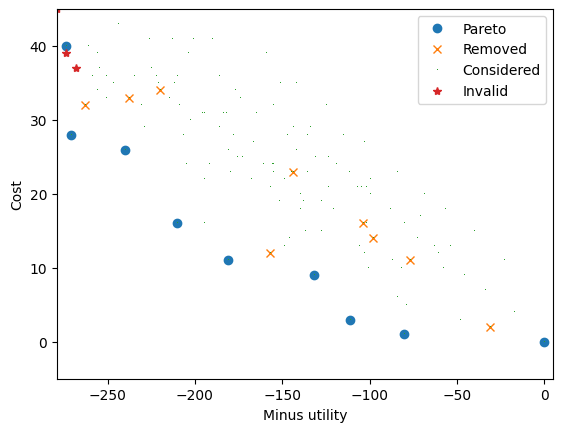

In [18]:
_ = the_pareto.plot(label_x='Minus utility', label_y='Cost')